<a href="https://colab.research.google.com/github/ahmedinB/Computer-Vision-Fundamentals/blob/main/FasterRCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Faster RCNN Implemention

In [1]:
pip install kagglehub

In [2]:
# @title
# imports
import numpy as np
import pandas as pd
import os, copy, sys, math, cv2, torch, torchvision
from tqdm.notebook import tqdm
from torchvision import datasets, models
from torchvision.transforms import functional as FT
from torchvision import transforms as T
from torch import nn, optim
from torch.utils.data import DataLoader, sampler, random_split, Dataset
from PIL import Image
import albumentations as A
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
from albumentations.pytorch import ToTensorV2


In [3]:
import kagglehub

# os.environ['KAGGLEHUB_CACHE'] = '/content/'
path = kagglehub.dataset_download('sharansmenon/aquarium-dataset')

print('Dataset path: ', path)

Using Colab cache for faster access to the 'aquarium-dataset' dataset.
Dataset path:  /kaggle/input/aquarium-dataset


In [4]:
dataset_path = path + "/Aquarium Combined"

In [5]:
# def get_transforms
# @title
def get_transforms(train=False):
  if train:
    transform = A.Compose([
        A.Resize(600, 600),
        A.HorizontalFlip(p=0.3),
        A.VerticalFlip(p=0.3),
        A.RandomBrightnessContrast(p=0.1),
        A.ColorJitter(p=0.1),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='coco'))
  else:
    transform = A.Compose([A.Resize(600, 600),
                           ToTensorV2()
                           ],
                          bbox_params= A.BboxParams(format='coco'))
  return transform

In [6]:
# @title
class Detection(datasets.VisionDataset):
  def __init__(self, root, split='train', transform=None, target_transform=None, transforms = None):
    super().__init__(root, transforms, transform, target_transform)
    self.split = split
    self.coco = COCO(os.path.join(root, split, "_annotations.coco.json"))
    self.ids = list(sorted(self.coco.imgs.keys()))
    self.ids = [id for id in self.ids if (len(self._load_target(id))>0)]

  def _load_image(self, id:int):
    path = self.coco.loadImgs(id)[0]["file_name"]
    image = cv2.imread(os.path.join(self.root, self.split, path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

  def _load_target(self, id:int):
    return self.coco.loadAnns(self.coco.getAnnIds(id))

  def __getitem__(self, index):
    id = self.ids[index]
    image = self._load_image(id)
    target = self._load_target(id)
    target = copy.deepcopy(target)

    boxes = [t['bbox'] + [t['category_id']] for t in target]
    if self.transforms is not None:
      transformed = self.transforms(image=image, bboxes=boxes)

    image = transformed['image']
    boxes = transformed['bboxes']

    new_boxes = []
    for box in boxes:
      xmin = box[0]
      xmax = xmin + box[2]
      ymin = box[1]
      ymax = ymin + box[3]
      new_boxes.append([xmin, ymin, xmax, ymax])

    boxes = torch.tensor(new_boxes, dtype=torch.float32)

    targ = {}
    targ['boxes'] = boxes
    targ['labels'] = torch.tensor([t['category_id'] for t in target], dtype=torch.int64)
    targ['image_id'] = torch.tensor([t['image_id'] for t in target])
    targ['area'] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
    targ['iscrowd'] = torch.tensor([t['iscrowd'] for t in target], dtype= torch.int64)
    return image.div(255), targ

  def __len__(self):
    return len(self.ids)

In [7]:
coco = COCO(os.path.join(dataset_path, "train", "_annotations.coco.json"))
categories = coco.cats
n_classes = len(categories.keys())
categories

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!


{0: {'id': 0, 'name': 'creatures', 'supercategory': 'none'},
 1: {'id': 1, 'name': 'fish', 'supercategory': 'creatures'},
 2: {'id': 2, 'name': 'jellyfish', 'supercategory': 'creatures'},
 3: {'id': 3, 'name': 'penguin', 'supercategory': 'creatures'},
 4: {'id': 4, 'name': 'puffin', 'supercategory': 'creatures'},
 5: {'id': 5, 'name': 'shark', 'supercategory': 'creatures'},
 6: {'id': 6, 'name': 'starfish', 'supercategory': 'creatures'},
 7: {'id': 7, 'name': 'stingray', 'supercategory': 'creatures'}}

In [8]:
classes = [i[1]['name'] for i in categories.items()]
classes

['creatures',
 'fish',
 'jellyfish',
 'penguin',
 'puffin',
 'shark',
 'starfish',
 'stingray']

In [9]:
train_dataset = Detection(root=dataset_path, transforms=get_transforms(train=True))

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


/tmp/ipython-input-89550771.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_int = torch.tensor(sample[0]*255, dtype=torch.uint8)


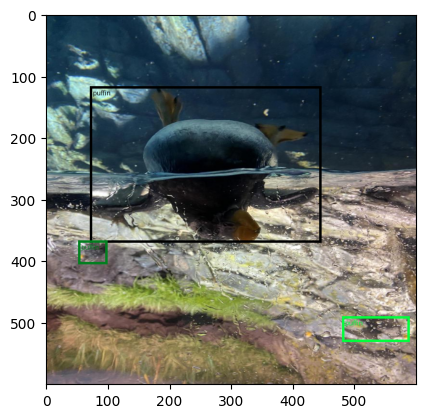

In [10]:
from torchvision.utils import draw_bounding_boxes
sample = train_dataset[2]
img_int = torch.tensor(sample[0]*255, dtype=torch.uint8)
plt.imshow(draw_bounding_boxes(
    img_int, sample[1]['boxes'],[classes[i] for i in sample[1]['labels']], width=4
    ).permute(1, 2, 0))

In [11]:
len(train_dataset)

447

In [12]:
model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, n_classes)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 93.1MB/s]


In [13]:
def collate_fn(batch):
  return tuple(zip(*batch))

In [14]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4, collate_fn = collate_fn)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [15]:
images, targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k:v for k, v in t.items()} for t in targets]
output = model(images, targets)

In [16]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = model.to(device)


In [17]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True, weight_decay = 1e-4)


In [18]:
# @title
def train_one_epoch(model, optimizer, loader, device, epoch):
  model.to(device)
  model.train()

  all_losses = []
  all_losses_dict = []

  for images, targets in tqdm(loader):
    images = list(image.to(device) for image in images)
    targets = [{k:torch.tensor(v).to(device) for k, v in t.items()} for t in targets]

    loss_dict = model(images, targets)
    losses = sum(loss for loss in loss_dict.values())
    loss_dict_append = {k:v.item() for k, v in loss_dict.items()}
    loss_value = losses.item()

    all_losses.append(loss_value)
    all_losses_dict.append(loss_dict_append)

    if not math.isfinite(loss_value):
      print(f"Loss is {loss_value}, stopping training")
      print(loss_dict)
      sys.exit(1)

    optimizer.zero_grad()
    losses.backward()
    optimizer.step()
  all_losses_dict = pd.DataFrame(all_losses_dict)
  print("Epoch {}, lr: {:.6f}, loss: {:.6f}, loss_classifier: {:.6f}, loss_box: {:0.6f}, loss_rpn_box:{:.6f}, loss_object: {:.6f}".format(
        epoch, optimizer.param_groups[0]['lr'], np.mean(all_losses),
        all_losses_dict['loss_classifier'].mean(),
        all_losses_dict['loss_box_reg'].mean(),
        all_losses_dict['loss_rpn_box_reg'].mean(),
        all_losses_dict['loss_objectness'].mean()))

In [19]:
num_epoches = 10
for epoch in range(num_epoches):
  train_one_epoch(model, optimizer, train_loader, device, epoch)


  0%|          | 0/112 [00:00<?, ?it/s]

/tmp/ipython-input-343974367.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = [{k:torch.tensor(v).to(device) for k, v in t.items()} for t in targets]


Epoch 0, lr: 0.010000, loss: 1.009583, loss_classifier: 0.487536, loss_box: 0.404617, loss_rpn_box:0.031857, loss_object: 0.085573


  0%|          | 0/112 [00:00<?, ?it/s]

Epoch 1, lr: 0.010000, loss: 0.806038, loss_classifier: 0.375159, loss_box: 0.342087, loss_rpn_box:0.029675, loss_object: 0.059117


...

Epoch 7, lr: 0.010000, loss: 0.637584, loss_classifier: 0.240755, loss_box: 0.347551, loss_rpn_box:0.021071, loss_object: 0.028207


  0%|          | 0/112 [00:00<?, ?it/s]

Epoch 8, lr: 0.010000, loss: 0.622119, loss_classifier: 0.239797, loss_box: 0.329444, loss_rpn_box:0.021387, loss_object: 0.031491


  0%|          | 0/112 [00:00<?, ?it/s]

Epoch 9, lr: 0.010000, loss: 0.596692, loss_classifier: 0.220759, loss_box: 0.329604, loss_rpn_box:0.021036, loss_object: 0.025294


In [20]:
model.eval()
torch.cuda.empty_cache()

In [21]:
test_dataset = Detection(root=dataset_path, split='test', transforms=get_transforms(False))

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [22]:
img, _ = test_dataset[5]
img_int = torch.tensor(img*255, dtype=torch.uint8)
with torch.no_grad():
  prediction = model([img.to(device)])
  pred = prediction[0]


/tmp/ipython-input-653422586.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_int = torch.tensor(img*255, dtype=torch.uint8)


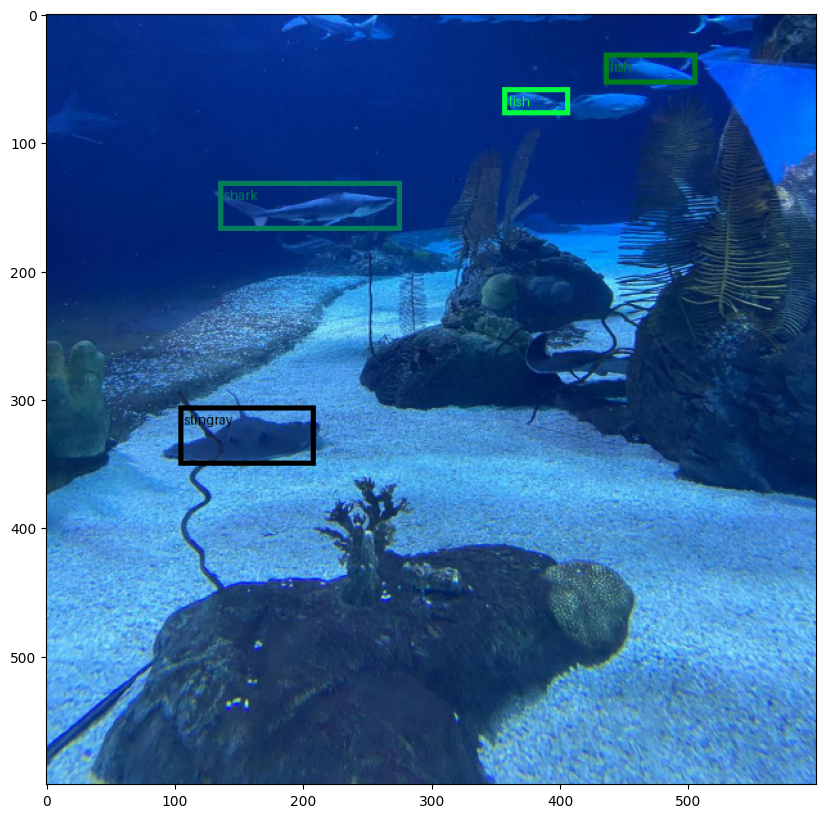

In [23]:
fig = plt.figure(figsize=(14, 10))
plt.imshow(draw_bounding_boxes(img_int, pred['boxes'][pred['scores'] > 0.8],
                               [classes[i] for i in pred['labels'][pred['scores'] > 0.8].tolist()], width = 4).permute(1,2,0))